# Phase 2: Backtest Results

This notebook runs the carry trade strategy on synthetic data and shows the results.

**What is backtesting?**
Replaying historical data and pretending to trade. It answers:
"If I had used these rules over the past year, would I have made money?"

In [1]:
import sys
sys.path.insert(0, '../..')

import matplotlib.pyplot as plt
import numpy as np
from src.config.settings import DEFAULT_PAIRS, StrategyConfig
from src.data.generator import SyntheticDataGenerator
from src.strategy.carry_trade import CarryTradeStrategy
from src.backtest.engine import BacktestEngine

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
# Generate data and run backtest
gen = SyntheticDataGenerator(seed=42)
data = gen.generate_all_pairs(days=365)

strategy = CarryTradeStrategy()
engine = BacktestEngine(strategy)

results = {}
for name, df in data.items():
    results[name] = engine.run(df, name)
    print(results[name].summary())
    print()

=== Backtest: USD/JPY ===
Total Return:        -0.42%
Annual Return:       -0.42%
Max Drawdown:         0.59%
Sharpe Ratio:         -0.10
Sortino Ratio:        -0.18
Calmar Ratio:         -0.71

Total Trades:             2
Win Rate:             50.0%
Profit Factor:         0.73
Avg Win:              21.62
Avg Loss:            -29.54

Total Swap Profit:    23.67
Swap Contribution:   -299.1%

=== Backtest: AUD/JPY ===
Total Return:       -55.44%
Annual Return:      -55.57%
Max Drawdown:        55.44%
Sharpe Ratio:        -13.10
Sortino Ratio:       -16.53
Calmar Ratio:         -1.00

Total Trades:           238
Win Rate:             12.6%
Profit Factor:         0.10
Avg Win:              16.49
Avg Loss:            -23.25

Total Swap Profit:    12.92
Swap Contribution:     -0.3%

=== Backtest: EUR/USD ===
Total Return:         0.00%
Annual Return:        0.00%
Max Drawdown:         0.00%
Sharpe Ratio:          0.00
Sortino Ratio:         0.00
Calmar Ratio:          0.00

Total Trades:    

## Equity Curves
The equity curve shows your account balance over time.
- Going UP = making money
- Going DOWN = losing money
- Flat = no open position or price not moving

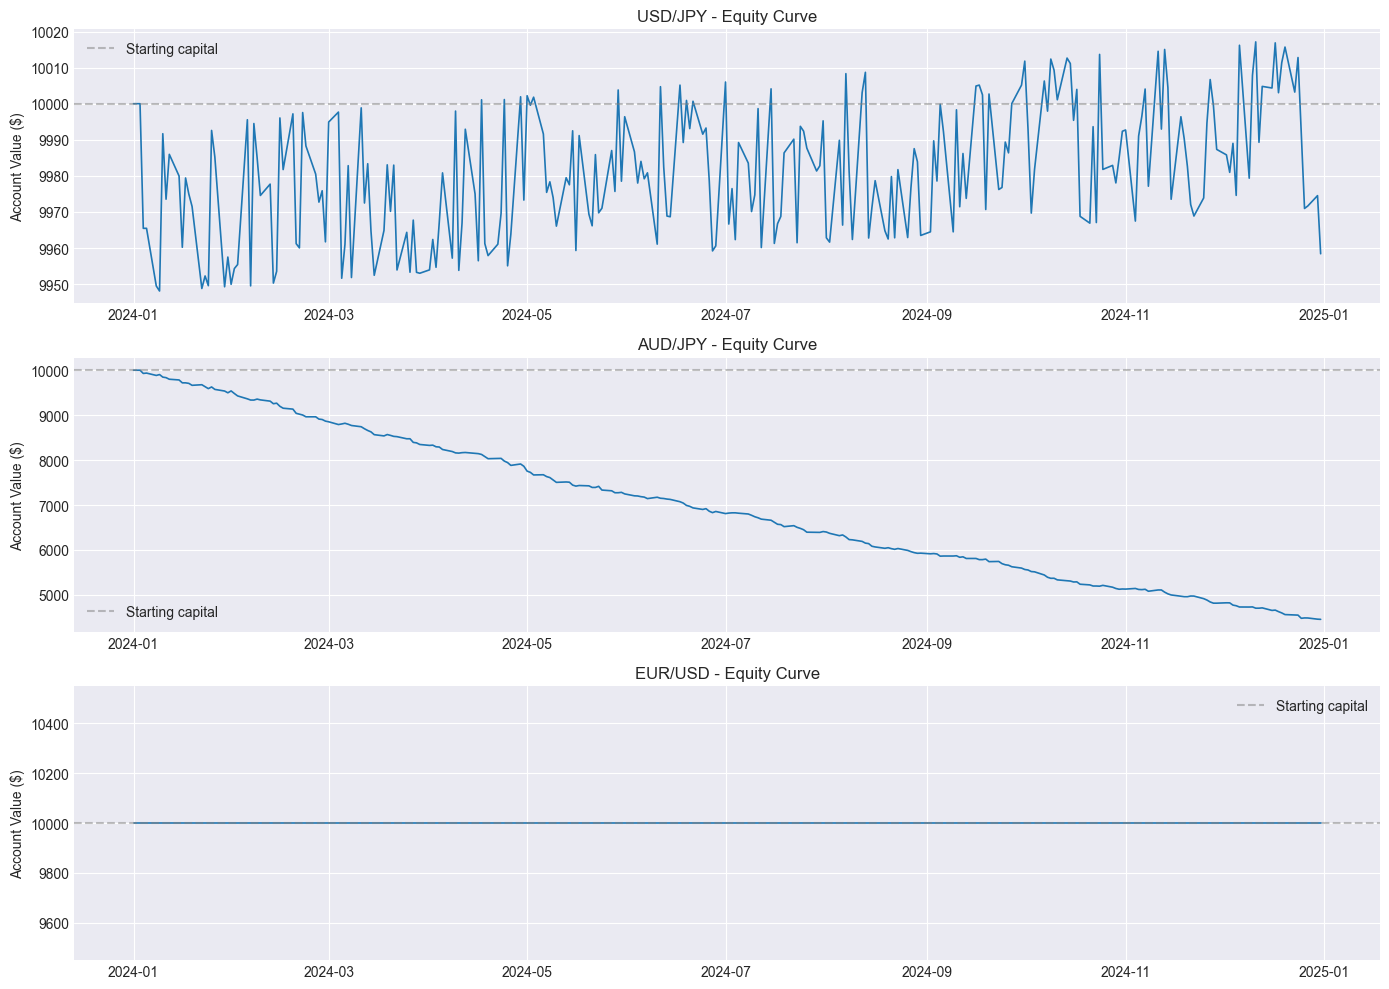

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (name, result) in zip(axes, results.items()):
    eq = result.equity_df
    if len(eq) > 0:
        ax.plot(eq['timestamp'], eq['equity'], linewidth=1.2)
        ax.axhline(10_000, color='gray', linestyle='--', alpha=0.5, label='Starting capital')
        ax.set_title(f'{name} - Equity Curve')
        ax.set_ylabel('Account Value ($)')
        ax.legend()
plt.tight_layout()
plt.show()

## Trade Entry/Exit Points
Green triangles = where the bot bought. Red triangles = where it sold.
Lots of red right after green = the stop loss keeps getting hit (bad).

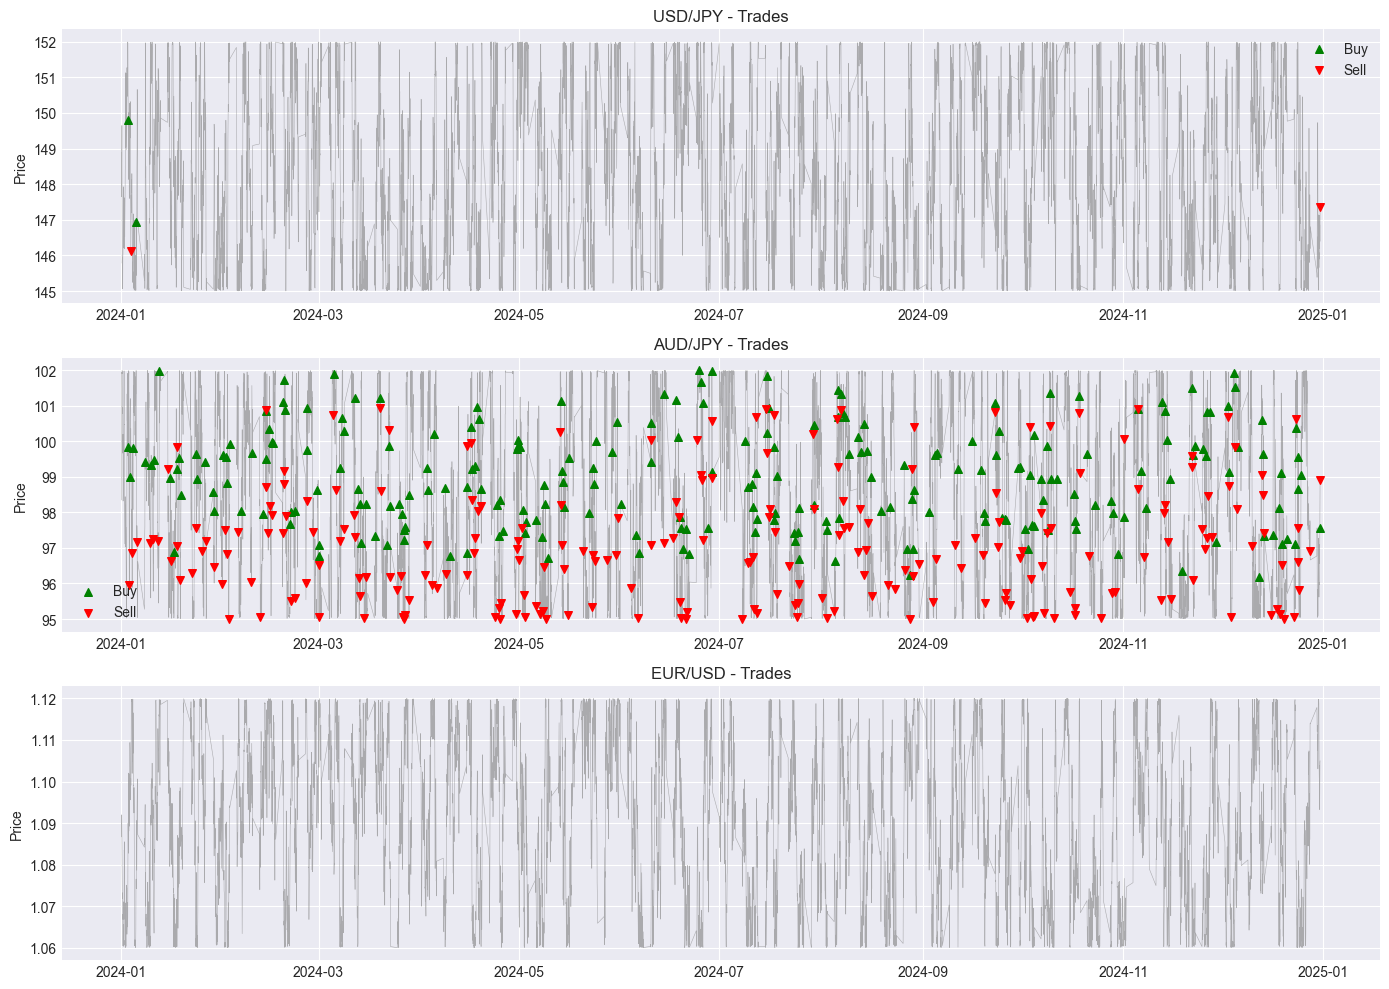

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, (name, result) in zip(axes, results.items()):
    df = data[name]
    ax.plot(df['timestamp'], df['close'], linewidth=0.4, alpha=0.6, color='gray')
    ax.set_title(f'{name} - Trades')
    ax.set_ylabel('Price')
    trades = result.trades_df
    if len(trades) > 0:
        ax.scatter(trades['entry_time'], trades['entry_price'],
                  marker='^', color='green', s=30, zorder=5, label='Buy')
        ax.scatter(trades['exit_time'], trades['exit_price'],
                  marker='v', color='red', s=30, zorder=5, label='Sell')
        ax.legend()
plt.tight_layout()
plt.show()

## Key Takeaway

The strategy loses money on AUD/JPY because the **stop loss is too tight**
for a volatile pair. The price swings more than 2% regularly, so the bot
keeps buying and getting stopped out. This is called **whipsaw**.

Phase 3 will optimize these parameters to find better settings.